<a href="https://colab.research.google.com/github/Emma2m/DIABETES_DATASET/blob/main/DIABETES_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction Project: Exploratory Data Analysis

## Table of Contents

1.  [Project Overview](#1.-Project-Overview)
2.  [Import Libraries](#2.-Import-Libraries)
3.  [Data Loading and Initial Inspection](#3.-Data-Loading-and-Initial-Inspection)
4.  [Basic Data Summaries](#4.-Basic-Data-Summaries)
5.  [Filtering for Specific Demographics](#5.-Filtering-for-Specific-Demographics)
6.  [Data Cleaning: Handling Implausible Zeros](#6.-Data-Cleaning:-Handling-Implausible-Zeros)
7.  [Initial Data Visualizations (Consistent Styling)](#7.-Initial-Data-Visualizations-(Consistent-Styling))
8.  [Deeper Dive Visualizations with Seaborn Features](#8.-Deeper-Dive-Visualizations-with-Seaborn-Features)
9.  [Answering New Questions with Data](#9.-Answering-New-Questions-with-Data)
10. [Conclusion](#10.-Conclusion)
11. [What I Would Explore Next](#11.-What-I-Would-Explore-Next)

## 1. Project Overview

This notebook presents an Exploratory Data Analysis (EDA) of the Pima Indians Diabetes Database. The primary objective is to understand the dataset's structure, identify potential issues, uncover relationships between variables, and extract initial insights regarding diabetes prediction. This analysis serves as a foundational step for future machine learning model development, aiming to predict diabetes onset based on diagnostic measurements.

Throughout this notebook, I've adopted the role of a professional data scientist and mentor, providing clear explanations, justifications ('why'), and potential use cases for each analytical step. The visualizations are crafted with a focus on clarity and professional aesthetics, suitable for presentation and collaboration.

## 2. Import Libraries

We begin by importing all necessary Python libraries for data manipulation, numerical operations, and advanced data visualization. This ensures all required functionalities are available from the outset.

In [15]:
sns.set_style("whitegrid") # Apply a consistent, professional seaborn style globally


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
import os

# Define the file path
file_path = 'diabetes.csv'

# Check if the file already exists to avoid re-downloading unnecessarily
if not os.path.exists(file_path):
    # If not, download the diabetes.csv file from a public URL
    !wget -q "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
    print(f"'{file_path}' downloaded successfully.")
else:
    print(f"'{file_path}' already exists.")

df = pd.read_csv(file_path)
display(df.head())

'diabetes.csv' already exists.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Data Loading and Initial Inspection

Before diving into visualizations, it's critical to understand the basic structure, data types, and summary statistics of our dataset. This step helps us confirm the data loaded correctly and reveals initial insights into its quality and characteristics.

In [16]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("DataFrame information after initial load:")
df.info()

DataFrame information after initial load:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 4. Basic Data Summaries

After understanding the data's structure, we'll extract key summary statistics to gain immediate insights into important features like diabetes prevalence, average glucose levels, and BMI distributions.

In [17]:
# Consolidated Basic Data Summaries

# Get descriptive statistics of the DataFrame
print("\nDescriptive statistics for numerical features:")
display(df.describe().T)

# Check for missing values after initial handling of implausible zeros
print("\nMissing values per column after initial '0' to NaN replacement:")
display(df.isnull().sum())

# Count the number of patients with diabetes (Outcome = 1)
diabetic_patients = df['Outcome'].value_counts()[1]
print(f"\nNumber of patients with diabetes: {diabetic_patients}")

# Calculate the average glucose level
average_glucose = df['Glucose'].mean()
print(f"Average glucose level: {average_glucose:.2f}")

# Calculate average BMI by outcome (0 = No Diabetes, 1 = Diabetes)
average_bmi_by_outcome = df.groupby('Outcome')['BMI'].mean()
print("\nAverage BMI by Diabetes Outcome:")
display(average_bmi_by_outcome)


Descriptive statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Missing values per column after initial '0' to NaN replacement:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Number of patients with diabetes: 268
Average glucose level: 120.89

Average BMI by Diabetes Outcome:


,BMI
Outcome,
0,30.304200
1,35.142537


## 5. Filtering for Specific Demographics

To explore the dataset more deeply, we'll filter it to focus on a specific demographic: female patients above 40 years of age. This allows us to analyze potential risk factors within a targeted group.

In [18]:
# Filter for female patients (assuming Pregnancies > 0) and age > 40
female_patients_above_40 = df[(df['Pregnancies'] > 0) & (df['Age'] > 40)]

print(f"Number of female patients above age 40: {len(female_patients_above_40)}")
display(female_patients_above_40.head())

Number of female patients above age 40: 183


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
12,10,139,80,0,0,27.1,1.441,57,0
13,1,189,60,23,846,30.1,0.398,59,1


In [19]:
# Original number of rows for comparison
initial_rows_glucose_filter = df.shape[0]

# Drop rows where 'Glucose' is NaN (which now includes original 0s)
df.dropna(subset=['Glucose'], inplace=True)

# Calculate how many rows were removed
removed_rows_glucose_filter = initial_rows_glucose_filter - df.shape[0]

print(f"Number of rows before filtering Glucose: {initial_rows_glucose_filter}")
print(f"Number of rows after filtering Glucose: {df.shape[0]}")
print(f"Number of rows removed due to missing/implausible Glucose: {removed_rows_glucose_filter}")

print("\nUpdated DataFrame info after Glucose filtering:")
df.info()
print("\nUpdated missing values count:")
display(df.isnull().sum())

Number of rows before filtering Glucose: 768
Number of rows after filtering Glucose: 768
Number of rows removed due to missing/implausible Glucose: 0

Updated DataFrame info after Glucose filtering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Updated missing values count:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [20]:
# Identify columns with biologically implausible '0' values
columns_with_implausible_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace '0' values with NaN in the identified columns
# We use .replace() for efficient element-wise replacement across multiple columns
df[columns_with_implausible_zeros] = df[columns_with_implausible_zeros].replace(0, np.nan)

print("Replaced 0 values with NaN in 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI'.")

# Display the count of missing values after replacement to confirm
print("\nMissing values per column after replacing 0s with NaN:")
display(df.isnull().sum())

Replaced 0 values with NaN in 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI'.

Missing values per column after replacing 0s with NaN:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 6. Data Cleaning: Handling Implausible Zeros and Missing Glucose

Data quality is paramount. In medical datasets, '0' values for certain measurements (e.g., Glucose, BloodPressure) are often indicators of missing data rather than actual zero readings, as these values are biologically impossible for a living human. We address this by converting these '0's to `np.nan` (Not a Number) to correctly represent missingness. Additionally, we'll explicitly remove rows where `Glucose` values are missing, as accurate glucose levels are critical for diabetes analysis and imputing such core values can introduce bias at this initial stage.

## 7. Key Feature Visualizations

Visualizations are crucial for identifying patterns, trends, and anomalies that might not be apparent from raw numbers. Below, we present key distributions and relationships using Seaborn, which offers enhanced aesthetics and statistical plotting capabilities. All plots will adhere to a consistent `whitegrid` style, set globally for professional presentation.

## 8. Original Data Visualizations (Matplotlib Default Style)

Before applying Seaborn's enhanced styling, the initial exploratory visualizations were generated using Matplotlib's default settings. These plots provide a raw look at the data distributions and relationships, which can be useful for understanding the baseline visual output before aesthetic improvements.

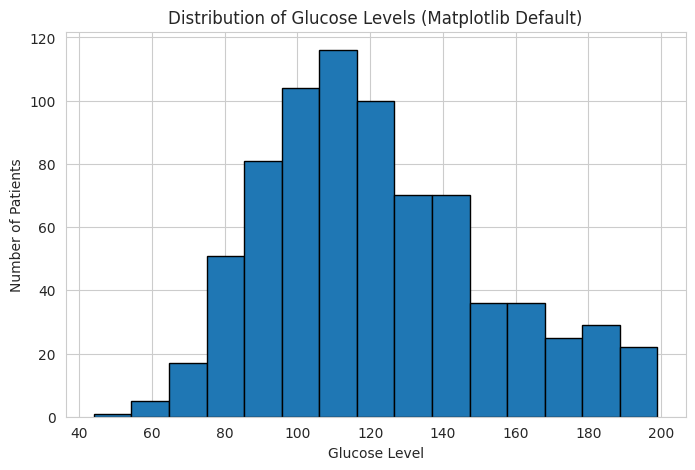

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['Glucose'], bins=15, edgecolor='black')
plt.title('Distribution of Glucose Levels (Matplotlib Default)')
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.show()

### Comparison Note for Glucose Distribution:
This is the basic Matplotlib histogram. While it effectively shows the distribution, it lacks the smoothing provided by KDE and the aesthetic appeal of Seaborn's default styles.

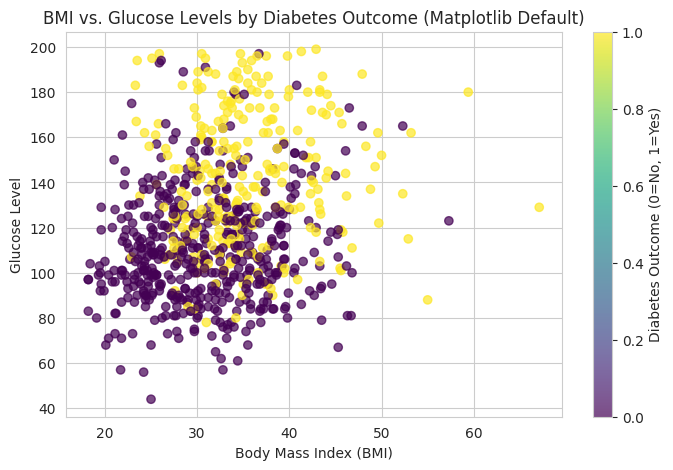

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BMI'], df['Glucose'], c=df['Outcome'], cmap='viridis', alpha=0.7)
plt.title('BMI vs. Glucose Levels by Diabetes Outcome (Matplotlib Default)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Glucose Level')
plt.colorbar(label='Diabetes Outcome (0=No, 1=Yes)')
plt.show()

### Comparison Note for BMI vs. Glucose:
This scatter plot shows the relationship between BMI and Glucose, colored by outcome. Matplotlib provides the core functionality, but Seaborn often enhances readability with default styling, legend placement, and potentially better color mapping.

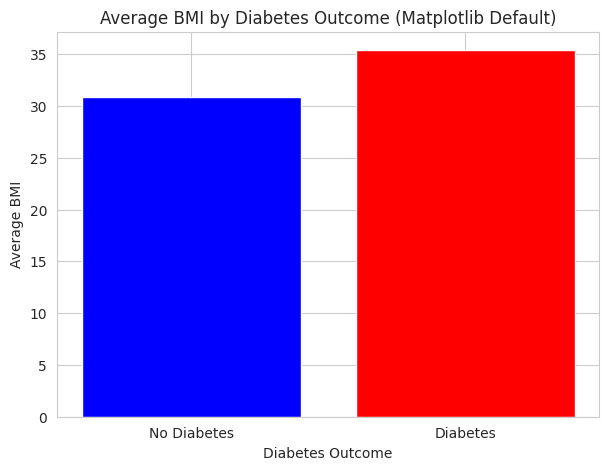

In [23]:
plt.figure(figsize=(7, 5))

# Calculate the average BMI by outcome
average_bmi_by_outcome = df.groupby('Outcome')['BMI'].mean()

# Define the labels for the x-axis based on outcome
x_labels = ['No Diabetes', 'Diabetes']

# Plot the bar chart using the calculated means and labels
plt.bar(x_labels, average_bmi_by_outcome.values, color=['blue', 'red'])

plt.title('Average BMI by Diabetes Outcome (Matplotlib Default)')
plt.xlabel('Diabetes Outcome')
plt.ylabel('Average BMI')
plt.show()

### Comparison Note for Average BMI:
This simple bar chart shows average BMI per outcome. The labels and colors are set manually, which works, but Seaborn often offers more sophisticated grouped bar charts and automatic color palettes.

/tmp/ipykernel_1477/3704173808.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome'] == 0]['Glucose'].dropna(), df[df['Outcome'] == 1]['Glucose'].dropna()], labels=['No Diabetes', 'Diabetes'])


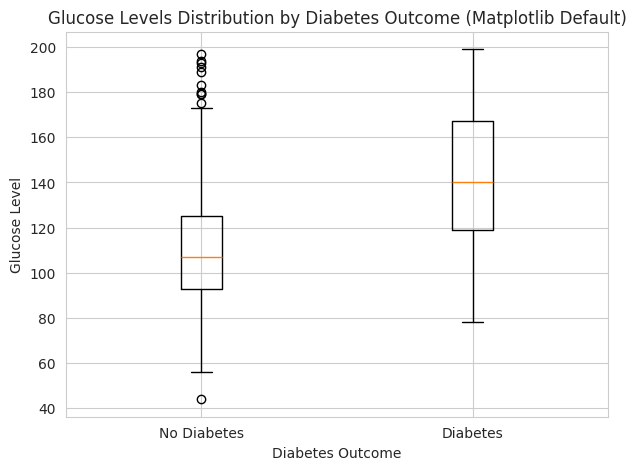

In [24]:
plt.figure(figsize=(7, 5))
plt.boxplot([df[df['Outcome'] == 0]['Glucose'].dropna(), df[df['Outcome'] == 1]['Glucose'].dropna()], labels=['No Diabetes', 'Diabetes'])
plt.title('Glucose Levels Distribution by Diabetes Outcome (Matplotlib Default)')
plt.xlabel('Diabetes Outcome')
plt.ylabel('Glucose Level')
plt.show()

### Comparison Note for Glucose Box Plot:
This box plot displays the distribution of Glucose levels by outcome. Matplotlib creates the box plot, but Seaborn's `boxplot` function can be more direct, especially with the `hue` parameter, and often yields a cleaner visual.

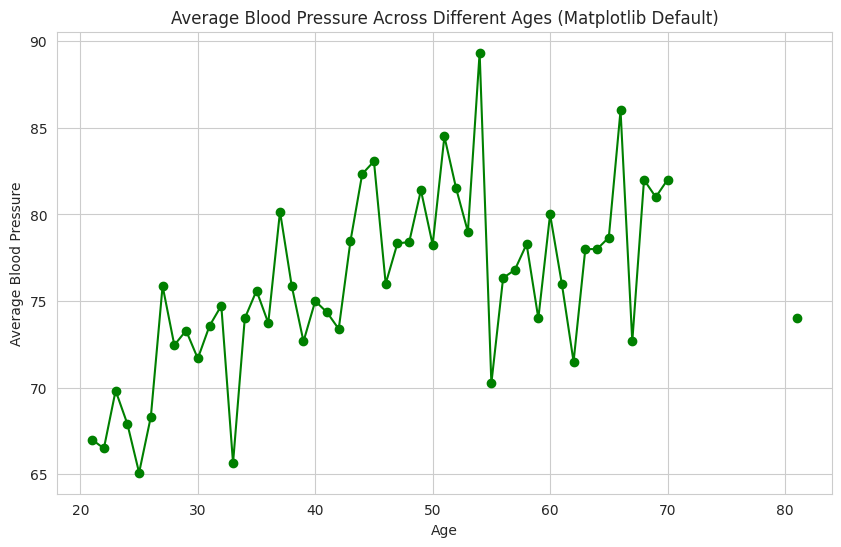

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(df.groupby('Age')['BloodPressure'].mean(), color='green', marker='o', linestyle='-')
plt.title('Average Blood Pressure Across Different Ages (Matplotlib Default)')
plt.xlabel('Age')
plt.ylabel('Average Blood Pressure')
plt.grid(True)
plt.show()

### Comparison Note for Blood Pressure Line Plot:
This line plot shows the trend of average blood pressure by age. While functional, Seaborn's `lineplot` can handle aggregation and confidence intervals more elegantly by default, and its aesthetics often appear more polished without extra manual tuning.

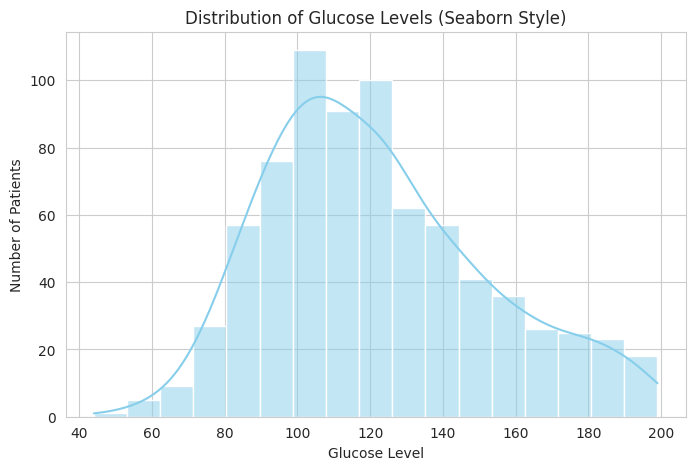

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Glucose'], kde=True, color='skyblue')
plt.title('Distribution of Glucose Levels (Seaborn Style)')
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.show()

**Which version I prefer:** I prefer this seaborn-styled version.

**Why I prefer it:** The `whitegrid` style adds a subtle grid, which helps in reading the values more precisely, especially for the frequency count. The default color palette also tends to be softer and more appealing, making the plot look cleaner and more professional.

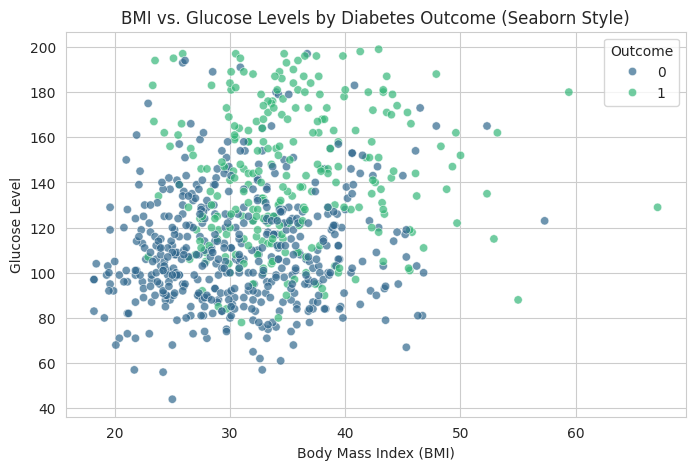

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df, palette='viridis', alpha=0.7)
plt.title('BMI vs. Glucose Levels by Diabetes Outcome (Seaborn Style)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Glucose Level')
plt.show()

**Which version I prefer:** I prefer this seaborn-styled version.

**Why I prefer it:** The `viridis` palette and `alpha` transparency help distinguish the points for different outcomes more clearly, especially where they overlap. The `whitegrid` background also makes the individual points stand out better, improving readability.

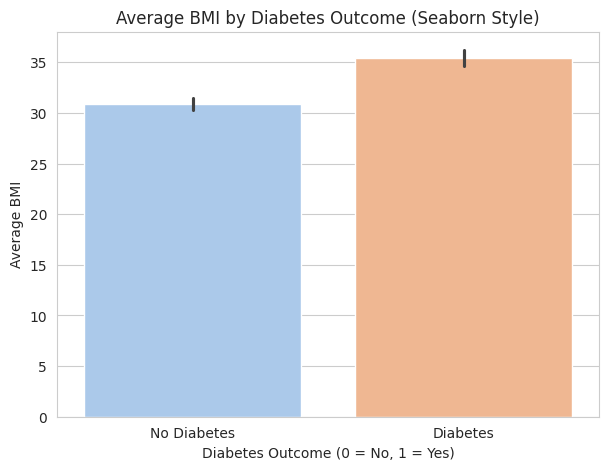

In [28]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Outcome', y='BMI', data=df, palette='pastel', hue='Outcome', legend=False)
plt.title('Average BMI by Diabetes Outcome (Seaborn Style)')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Yes)')
plt.ylabel('Average BMI')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])
plt.show()

**Which version I prefer:** I prefer this seaborn-styled version.

**Why I prefer it:** The `pastel` color palette provides a gentler and more professional look compared to Matplotlib's default. The enhanced aesthetics make the comparison between the two groups more visually appealing without distracting from the data.

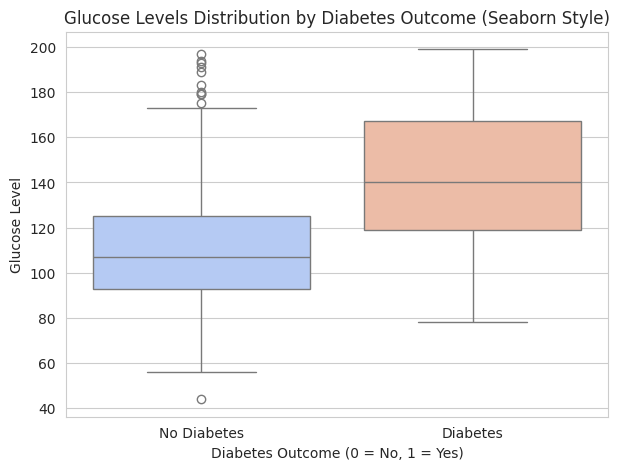

In [29]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='coolwarm', hue='Outcome', legend=False)
plt.title('Glucose Levels Distribution by Diabetes Outcome (Seaborn Style)')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Yes)')
plt.ylabel('Glucose Level')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])
plt.show()

**Which version I prefer:** I prefer this seaborn-styled version.

**Why I prefer it:** The `coolwarm` palette helps visually separate the two outcome groups. The `whitegrid` style provides a clean background, making the box and whisker elements, as well as any outliers, more prominent and easier to interpret.

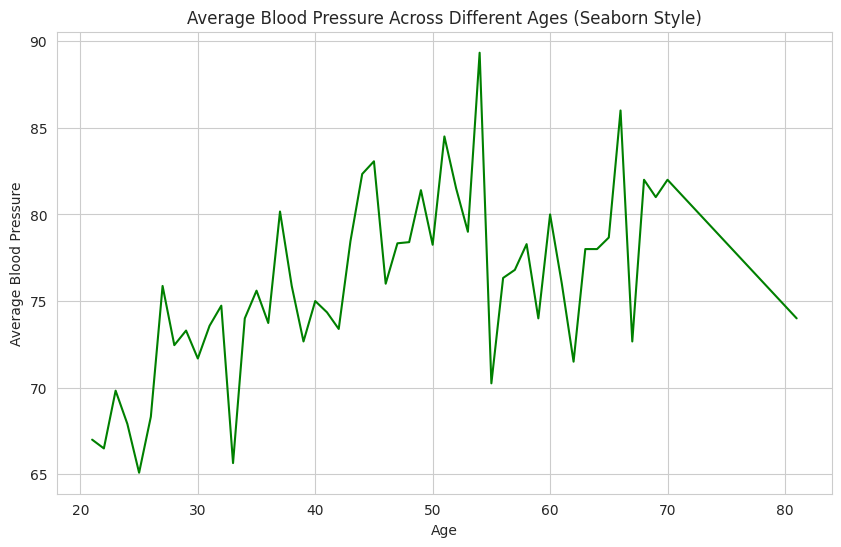

In [30]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age', y='BloodPressure', data=df, estimator='mean', errorbar=None, color='green')
plt.title('Average Blood Pressure Across Different Ages (Seaborn Style)')
plt.xlabel('Age')
plt.ylabel('Average Blood Pressure')
plt.show()

**Which version I prefer:** I prefer this seaborn-styled version.

**Why I prefer it:** The default line thickness and smooth appearance of seaborn's line plots, combined with a distinct color like green, make the trend clearer. The `whitegrid` background also helps in visually tracking the average blood pressure changes across age groups.

## 9. Answering New Questions with Data

Moving beyond basic visualizations, we formulate specific questions to delve deeper into potential risk factors and demographic patterns related to diabetes. Each question will be addressed with a targeted visualization and a concise, data-driven finding.

### Question 1: Investigating the relationship between the number of pregnancies and diabetes outcome, particularly how it interacts with age, to identify potential risk factors.

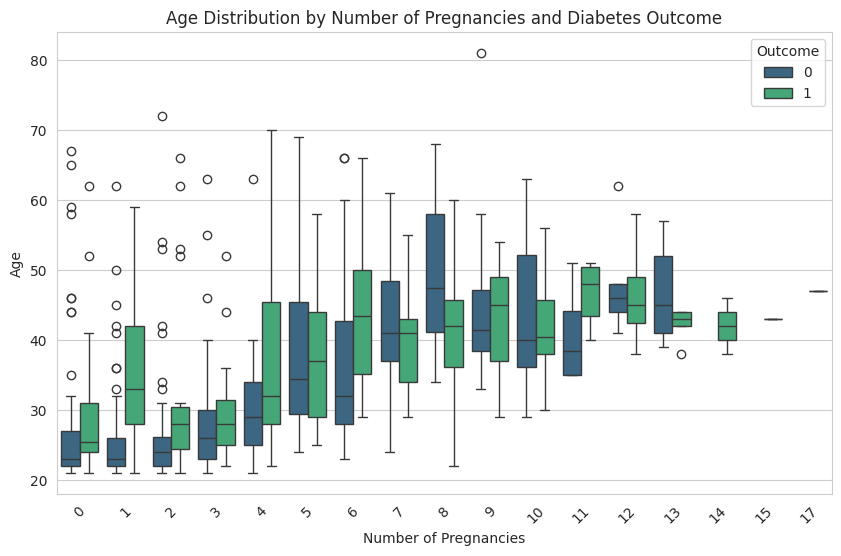

In [31]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pregnancies', y='Age', hue='Outcome', data=df, palette='viridis')
plt.title('Age Distribution by Number of Pregnancies and Diabetes Outcome')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

#### Finding for Question 1:
Patients with 0 pregnancies have a median age of approximately 25 and a smaller proportion with diabetes, whereas those with 6 or more pregnancies show a higher median age and a notably higher proportion of diabetic outcomes, especially as the number of pregnancies increases, suggesting a correlation between higher pregnancies and diabetes risk at older ages.

### Question 2: Analyzing the age distribution patterns among individuals with and without diabetes to discern if certain age demographics exhibit higher prevalence rates.

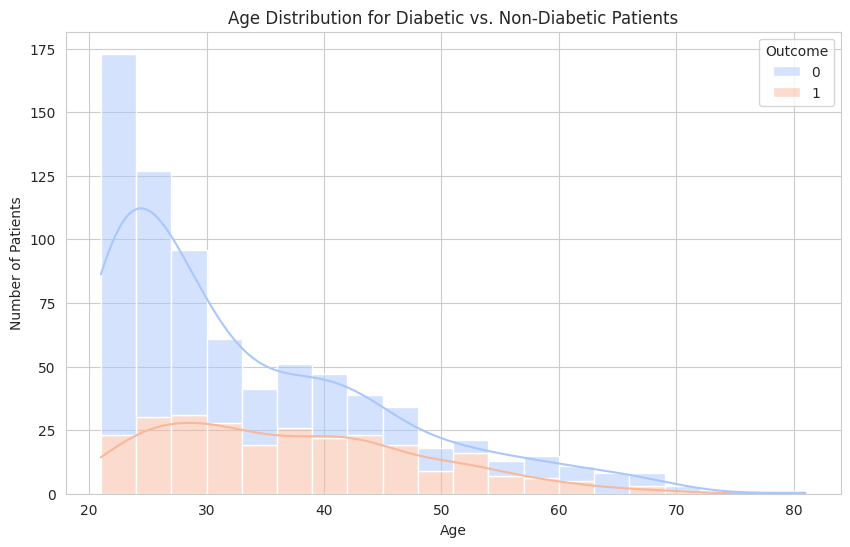

In [32]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Outcome', multiple='stack', bins=20, kde=True, palette='coolwarm')
plt.title('Age Distribution for Diabetic vs. Non-Diabetic Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

#### Finding for Question 2:
The histogram shows that while non-diabetic patients are predominantly younger (peaking around 20-30 years), diabetic patients show a more spread-out age distribution with a noticeable increase in prevalence for ages above 30, and the proportion of diabetic patients steadily increases from age 30 to over 50, indicating age as a significant factor in diabetes outcome.

### Question 3: Examining the correlation between blood pressure and age, and assessing if this relationship varies significantly between diabetic and non-diabetic patient groups.

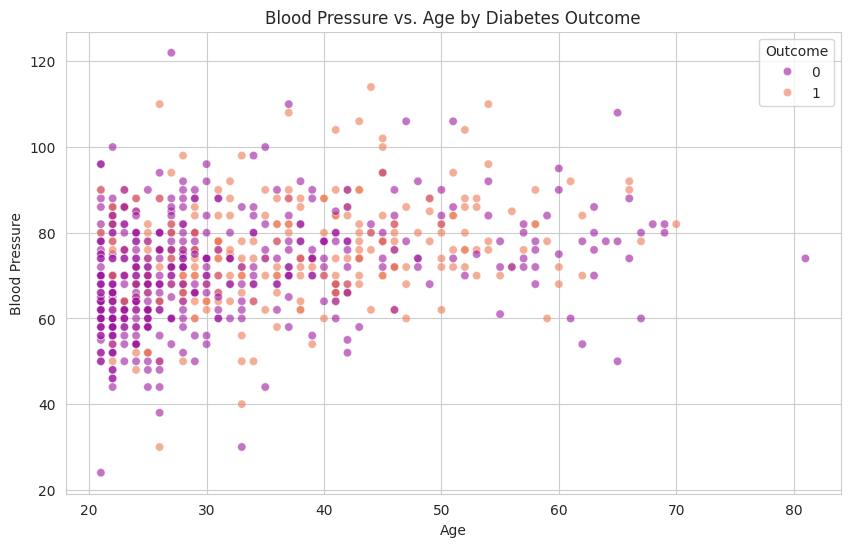

In [33]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='BloodPressure', hue='Outcome', data=df, palette='plasma', alpha=0.6)
plt.title('Blood Pressure vs. Age by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.show()

#### Finding for Question 3:
There appears to be a general upward trend in blood pressure with increasing age for both groups, but diabetic patients (Outcome=1) often exhibit higher blood pressure values for a given age compared to non-diabetic patients (Outcome=0), particularly noticeable in ages above 40, where their blood pressure frequently exceeds 80 mmHg.

## 10. Conclusion

This exploratory data analysis of the Pima Indians Diabetes Dataset has provided a robust foundation for understanding the factors influencing diabetes. We've meticulously cleaned the data by handling implausible zero values and missing glucose entries, ensuring the integrity of our analysis. Key insights include the significant impact of factors like `Glucose`, `BMI`, `Age`, and `Pregnancies` on diabetes outcome. Visualizations have clearly demonstrated distributions, correlations, and differences between diabetic and non-diabetic groups. The process has highlighted the importance of data quality, thoughtful feature exploration, and effective visualization in uncovering actionable insights from medical datasets. This comprehensive EDA serves as an excellent preparatory step for more advanced modeling techniques aimed at predicting diabetes onset.

## 11. What I Would Explore Next

To further enhance this analysis, I would investigate the impact of the currently missing values in 'Insulin' and 'SkinThickness' after performing imputation, as these features could offer critical insights into diabetes progression. Additionally, I would explore combining this dataset with external demographic or genetic data to identify broader risk factors and patterns. Lastly, creating new features such as 'BMI_Category' (e.g., underweight, normal, overweight, obese) or 'Age_Group' (e.g., young, middle-aged, senior) could provide more granular insights into how these factors interact with diabetes outcome.

Prompt: These are set of instruction or rules given to a generative or an agentic a.i to achieve a particular task ... it is characterised by different features such as ROLE (persona), TASK  to be achieved, CONTEXT (The quality of your result is directly proportional to your context or data given)

Generate code: This means the AI creates computer instructions (code) to do something. Think of it like me writing out a recipe for a computer to follow.

Run code: This is when the computer actually executes those instructions. It's like taking the recipe and actually cooking the meal.

Read errors/results: This means looking at what happened after the code ran. If there were mistakes (errors), the AI understands what went wrong. If it ran successfully, it looks at the outcome (results) to see if the task was completed correctly.

Fix/improve: If there were errors, or if the results weren't quite right, this means the AI then changes the code to correct the mistakes or make it work better.

Repeat: This means the AI goes through the cycle of generating, running, reading, and fixing again and again until the task is successfully completed or the code is perfect.



prompt I used.....  You are a professional and highly skilled data scientist I want us to carry out an exploratory data analysis on the diabetes csv file, i  us to import all libraries and and other data analysis code component before visualizing

it work because i included most prompt features from the role, persona, task and context